In [ ]:
using CSV 
using DataFrames

using Turing
using KernelFunctions
using LinearAlgebra

using ReverseDiff
using Plots

using MCMCChains

using Revise
using BayesSoundSource

In [2]:
microphone_coords = [
    [0.0, 0.0],
    [-5.0, 1.5],
    [5.0, 1.5],
    [0.0, 3],
]

receiver_priors = MvNormal.(microphone_coords, 0.1)

traj_prior = GPTrajPrior(2)
# traj_prior = FlatTrajPrior(2, [(-30.0,30.0), (-30.0,30.0)])

toa = [[0.01699190832936793, 0.027926458156141618, 0.00943107790527829, 0.011863184776026851], [0.21737939233125714, 0.2265239503245827, 0.21220887712788133, 0.21136689270217934], [0.4182070998580864, 0.42541545124638697, 0.4131580990990733, 0.41098006991123665], [0.6187030930531061, 0.6249716792951779, 0.6156618149858606, 0.6111529317262068], [0.8199323888041838, 0.8252729386720669, 0.8180926986416887, 0.8116895761147849]]
tdoa = [[-0.00957092269273787, 0.008222789257392307, 0.0048833991812489335, 0.01748075708484205, 0.01535431608929262, -0.0015670244947035912], [-0.008880345296712099, 0.006761007611149286, 0.006293606757214, 0.014505562120191525, 0.014741781716305427, 0.000574912888873092], [-0.007861803768256898, 0.004055443880846481, 0.006091606451978149, 0.012390836132740788, 0.0155086167662059, 0.0024190765451260693], [-0.006234215729524599, 0.004178606920719555, 0.007377175890019388, 0.009143871978038646, 0.015175370979975051, 0.0044749513716838465], [-0.004218743419776025, 0.0022779234093992895, 0.008692702984960329, 0.00639207282821201, 0.012317526218764238, 0.006961583851136868]]
# tdoa = [[missing, 0.008222789257392307, 0.0048833991812489335, 0.01748075708484205, 0.01535431608929262, -0.0015670244947035912], [-0.008880345296712099, 0.006761007611149286, 0.006293606757214, 0.014505562120191525, 0.014741781716305427, 0.000574912888873092], [-0.007861803768256898, 0.004055443880846481, 0.006091606451978149, 0.012390836132740788, 0.0155086167662059, 0.0024190765451260693], [-0.006234215729524599, 0.004178606920719555, 0.007377175890019388, 0.009143871978038646, 0.015175370979975051, 0.0044749513716838465], [-0.004218743419776025, 0.0022779234093992895, 0.008692702984960329, 0.00639207282821201, 0.012317526218764238, 0.006961583851136868]]

# Q = pairwise_difference_matrix(4)
# Qs = [Q[.!ismissing.(tdoa_z), :] for tdoa_z ∈ tdoa]
# tdoa_skip = collect.(skipmissing.(tdoa))
model = toa_tdoa_model(tdoa, toa, receiver_priors, traj_prior)

chn = sample(model, NUTS(; adtype=AutoReverseDiff(compile=true)), 500; 
    initial_params=InitFromPrior(),
    chain_type=MCMCChains.Chains)
describe(chn)

Sampling   0%|                                          |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.0015625
└ @ Turing.Inference /home/stephen/.julia/packages/Turing/WteH7/src/mcmc/hmc.jl:191
Sampling   1%|▎                                         |  ETA: 1:30:44
Sampling   1%|▌                                         |  ETA: 0:45:16
Sampling   2%|▋                                         |  ETA: 0:30:01
Sampling   2%|▉                                         |  ETA: 0:23:55
Sampling   3%|█▏                                        |  ETA: 0:18:47
Sampling   3%|█▎                                        |  ETA: 0:15:26
Sampling   4%|█▌                                        |  ETA: 0:13:10
Sampling   4%|█▋                                        |  ETA: 0:11:59
Sampling   5%|█▉                                        |  ETA: 0:10:39
Sampling   5%|██▏                                       |  ETA: 0:09:36
Sampling   6%|██▍                                       |  ETA: 0:08:45
Sampli

Chains MCMC chain (500×43×1 Array{Float64, 3}):

Iterations        = 251:1:750
Number of chains  = 1
Samples per chain = 500
Wall duration     = 59.12 seconds
Compute duration  = 59.12 seconds
parameters        = receivers[1, 1], receivers[2, 1], receivers[1, 2], receivers[2, 2], receivers[1, 3], receivers[2, 3], receivers[1, 4], receivers[2, 4], sos, σ_toa, σ_tdoa, t[1], t[2], t[3], t[4], t[5], traj.ℓ, traj.σ_noise, traj.σ_rbf, traj.coords[1, 1], traj.coords[2, 1], traj.coords[3, 1], traj.coords[4, 1], traj.coords[5, 1], traj.coords[1, 2], traj.coords[2, 2], traj.coords[3, 2], traj.coords[4, 2], traj.coords[5, 2]
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, logprior, loglikelihood, logjoint

Summary Statistics

       parameters       mean       std      mcse   ess_bulk   ess_tail      rh ⋯
           Symbol    Float64   Float64   

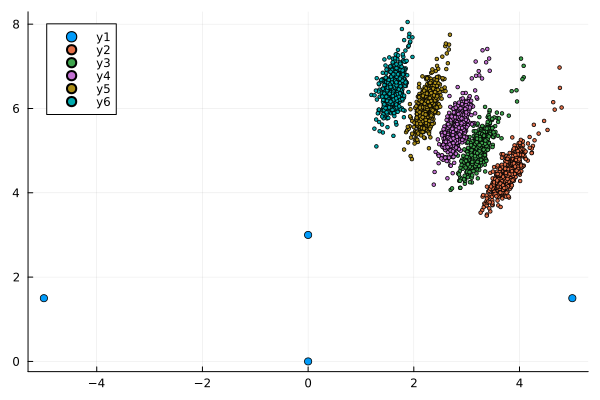

In [ ]:
trajs = extract_traj(chn, 2, 5)

p = scatter(Tuple.(microphone_coords))
for z ∈ 1:5 
    scatter!(p, trajs[z, 1, :], trajs[z, 2, :], m=2)
end 
p

In [14]:
microphone_coords = [
    [0.0, 0.0, 0.0],
    [-8.0, 0.0, 0.89],
    [0.0, 8.0, 1.65],
    [8.0, 0.0, 0.92],
    [0.0, -8.0, 1.64]
]


folder  = "/home/stephen/Documents/Field-data/bat_oct25/extracts/20251021_173336"
data = CSV.read(joinpath(folder, "GCC_tdoa_data.csv"), DataFrame)


tdoa_set = collect(eachrow(Array(data[!, ["tdoa_$(i)_$j" for i ∈ 1:5 for j ∈ i+1:5]])))
toa_set = collect(eachrow(Array(data[!, ["toa_$(i)" for i ∈ 1:5]])))
outlier_resp = collect(eachrow(Array(data[!, ["outlier_resp_$(i)_$j" for i ∈ 1:5 for j ∈ i+1:5]])))

outlier_filt = map(o -> all(o .< 0.1) , outlier_resp)

tdoa_set = tdoa_set[outlier_filt]
toa_set = toa_set[outlier_filt]
data

Row,tdoa_1_2,tdoa_1_3,tdoa_1_4,tdoa_1_5,tdoa_2_3,tdoa_2_4,tdoa_2_5,tdoa_3_4,tdoa_3_5,tdoa_4_5,toa_1,toa_2,toa_3,toa_4,toa_5,outlier_resp_1_2,outlier_resp_1_3,outlier_resp_1_4,outlier_resp_1_5,outlier_resp_2_3,outlier_resp_2_4,outlier_resp_2_5,outlier_resp_3_4,outlier_resp_3_5,outlier_resp_4_5
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.00659896,-0.0197135,0.00580729,-0.0215469,-0.0247917,-0.00529167,-0.0346562,0.0260365,0.00223958,-0.0236823,0.0185,0.0135,0.0385,0.0125,0.0395,1.0,0.0128217,0.00905534,0.0145534,0.0154395,1.0,1.0,0.132768,0.0128857,1.0
2,0.00419792,-0.0197135,0.00611458,0.0208646,-0.021776,-0.00425521,0.0163594,0.0216823,0.0405677,0.0148646,0.1095,0.1015,0.1275,0.1045,0.0905,1.0,0.0104879,0.00749975,1.0,0.00759846,1.0,0.999813,0.0139468,1.0,0.0132674
3,0.00419792,-0.0197135,0.00611458,-0.0209479,-0.021776,-0.00425521,-0.0200052,0.0216823,-0.00215625,-0.0201875,0.1095,0.1015,0.1275,0.1045,0.1315,1.0,0.0104669,0.00753051,0.999826,0.00752416,1.0,1.0,0.0140895,0.0105445,1.0
4,0.0243906,-0.00216667,0.031,-0.00858333,-0.021776,-0.00425521,-0.0200052,0.0216823,-0.00215625,-0.0201875,0.1245,0.1015,0.1275,0.1045,0.1315,0.00931389,1.0,1.0,0.0107001,0.00756246,1.0,1.0,0.0141053,0.0105754,1.0
5,0.0243906,-0.00216667,-0.0296615,-0.00858333,-0.021776,-0.0393854,-0.0200052,-0.0194635,-0.00215625,0.0115937,0.1245,0.1015,0.1275,0.1465,0.1315,0.00948621,1.0,1.0,0.0106604,0.00755736,1.0,1.0,1.0,0.0105974,0.0200133
6,-0.0124948,-0.00175521,0.00560417,0.0204479,0.0134948,0.0174583,0.032974,0.00564062,0.0267969,0.015526,0.2145,0.2275,0.2205,0.2095,0.1945,1.0,1.0,0.00768107,1.0,1.0,0.0138896,0.0111933,1.0,1.0,0.00876826
7,-0.0124948,-0.0200885,0.00560417,0.0204479,-0.00764583,0.0174583,0.032974,0.0251458,0.0406042,0.015526,0.2145,0.2275,0.2345,0.2095,0.1945,1.0,0.0109317,0.00765214,1.0,1.0,0.0140678,0.011345,0.014048,1.0,0.00856815
8,0.0240156,-0.00461979,-0.0218594,-0.00722396,-0.0246146,-0.0409062,-0.0298906,-0.0206823,-0.0115156,0.0140677,0.3145,0.2925,0.3165,0.3365,0.3235,1.0,1.0,1.0,1.0,0.177302,1.0,1.0,1.0,0.0454618,0.00607263
9,0.00466667,-0.020125,0.00538542,0.0208542,-0.0194219,0.00328125,0.012875,0.0244167,0.0407344,0.0159479,0.3765,0.3705,0.3945,0.3735,0.3565,0.037649,0.0114606,0.00775106,0.989405,0.0102622,1.0,1.0,0.00955262,1.0,0.00672634


In [ ]:
ys = map(tdoa_set[outlier_filt]) do tdoa 
    y, _ = tdoa_mle(microphone_coords, tdoa, speed_of_sound)
    if !insupport(location_prior, y) 
        y = rand(location_prior)
    end 
    return y
end 



In [15]:
receiver_priors = MvNormal.(microphone_coords, 0.1)
traj_prior = GPTrajPrior(3)
# traj_prior = FlatTrajPrior()

model = toa_tdoa_model(tdoa_set, toa_set, receiver_priors, traj_prior)

# init = @vnt begin
#         sos := speed_of_sound
#         y := ys
#         x := microphone_coords
#         # σ_tdoa := 1.0
#         σ_toa := 0.0005
#     end

chn = sample(model, 
    NUTS(; adtype=AutoReverseDiff(compile=true)), 
    300; 
    initial_params=InitFromPrior(),
    chain_type=MCMCChains.Chains)
    
describe(chn)

#         @time  chn = sample(model, 
#             NUTS(; adtype=AutoReverseDiff(compile=true)), 
#             MCMCThreads(),
#             1000, repeats; discard_adapt = true, verbose=false,
#             initial_params=fill((InitFromParams(init)), repeats))


Sampling   0%|                                          |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 9.765625e-5
└ @ Turing.Inference /home/stephen/.julia/packages/Turing/WteH7/src/mcmc/hmc.jl:191
Sampling   1%|▎                                         |  ETA: 0:00:51
Sampling   1%|▌                                         |  ETA: 0:00:31
Sampling   2%|▋                                         |  ETA: 0:00:23
Sampling   2%|▉                                         |  ETA: 0:00:18
Sampling   3%|█▏                                        |  ETA: 0:00:18
Sampling   3%|█▎                                        |  ETA: 0:00:33
Sampling   4%|█▌                                        |  ETA: 0:01:32
Sampling   4%|█▋                                        |  ETA: 0:01:47
Sampling   5%|██                                        |  ETA: 0:01:55
Sampling   5%|██▏                                       |  ETA: 0:02:47
Sampling   6%|██▍                                       |  ETA: 0:03:23
Samp

Chains MCMC chain (300×127×1 Array{Float64, 3}):

Iterations        = 151:1:450
Number of chains  = 1
Samples per chain = 300
Wall duration     = 700.64 seconds
Compute duration  = 700.64 seconds
parameters        = receivers[1, 1], receivers[2, 1], receivers[3, 1], receivers[1, 2], receivers[2, 2], receivers[3, 2], receivers[1, 3], receivers[2, 3], receivers[3, 3], receivers[1, 4], receivers[2, 4], receivers[3, 4], receivers[1, 5], receivers[2, 5], receivers[3, 5], sos, σ_toa, σ_tdoa, t[1], t[2], t[3], t[4], t[5], t[6], t[7], t[8], t[9], t[10], t[11], t[12], t[13], t[14], t[15], t[16], t[17], t[18], t[19], t[20], t[21], t[22], t[23], traj.ℓ, traj.σ_noise, traj.σ_rbf, traj.coords[1, 1], traj.coords[2, 1], traj.coords[3, 1], traj.coords[4, 1], traj.coords[5, 1], traj.coords[6, 1], traj.coords[7, 1], traj.coords[8, 1], traj.coords[9, 1], traj.coords[10, 1], traj.coords[11, 1], traj.coords[12, 1], traj.coords[13, 1], traj.coords[14, 1], traj.coords[15, 1], traj.coords[16, 1], traj.coords[


Sampling 100%|██████████████████████████████████████████| Time: 0:11:40




       parameters      mean       std      mcse   ess_bulk   ess_tail      rha ⋯
           Symbol   Float64   Float64   Float64    Float64    Float64   Float6 ⋯

  receivers[1, 1]   -0.0381    0.0883    0.0072   147.9379   124.2694    1.005 ⋯
  receivers[2, 1]    0.1512    0.0854    0.0143    35.6261   106.9789    0.999 ⋯
  receivers[3, 1]   -0.0794    0.0917    0.0160    33.5117   147.6978    0.998 ⋯
  receivers[1, 2]   -7.9945    0.0905    0.0093    95.3443   166.1618    0.998 ⋯
  receivers[2, 2]    0.0155    0.0936    0.0075   147.5889   173.7730    0.997 ⋯
  receivers[3, 2]    0.9297    0.1019    0.0075   180.9941   281.7791    1.004 ⋯
  receivers[1, 3]    0.0415    0.0997    0.0065   245.7917   318.7000    1.006 ⋯
  receivers[2, 3]    7.9232    0.0633    0.0063    98.6331   126.7979    1.001 ⋯
  receivers[3, 3]    1.6279    0.0900    0.0058   242.7205   215.2374    1.015 ⋯
  receivers[1, 4]    7.9012    0.0783    0.0054   209.3965   213.4990    1.008 ⋯
  receivers[2, 4]    0.00

In [ ]:
spead(chn, 3)

In [19]:
using Serialization 

serialize("chn_joint.bin", chn)